In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [7]:
fashion_mnist=keras.datasets.fashion_mnist   
(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()
print(X_train.shape,X_test.shape)


(60000, 28, 28) (10000, 28, 28)


In [10]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']


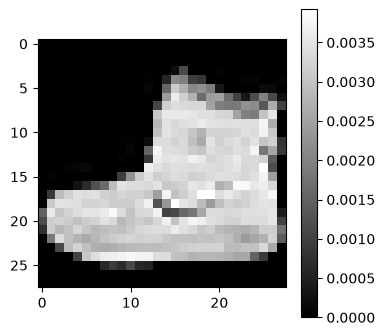

Actual Label: Ankle boot


In [18]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0], cmap='gray')
plt.colorbar()
plt.show()

print("Actual Label:", class_names[y_train[0]])

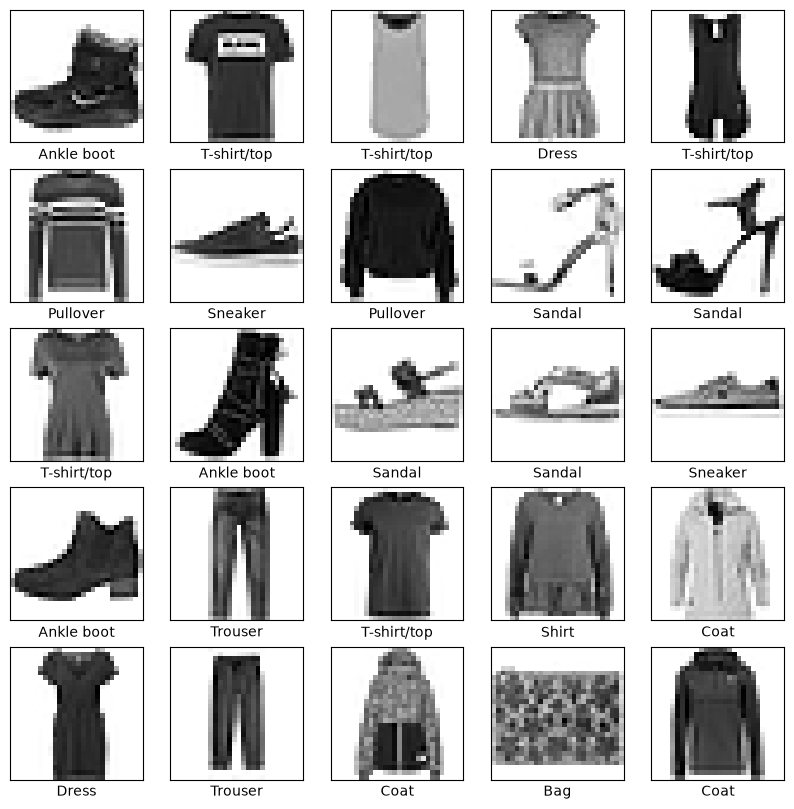

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i],cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]]) 

In [14]:
X_train=X_train/255.0
X_test=X_test/255.0
model=keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                         keras.layers.Dense(128,activation='relu'),
                         keras.layers.Dense(10,activation='softmax')])


c:\Users\bharath simha reddy\Desktop\genai_journey\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [16]:
model.fit(X_train,y_train,epochs=5)
test_loss,test_acc=model.evaluate(X_test,y_test)
print('Test accuracy:',test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.6532 - loss: 1.1056
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7680 - loss: 0.6488
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7951 - loss: 0.5710
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8127 - loss: 0.5276
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8239 - loss: 0.4993
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8159 - loss: 0.5130
Test accuracy: 0.8159000277519226


In [20]:
train_loss,train_acc=model.evaluate(X_train,y_train)
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Difference: {(train_acc-test_acc)*100:.2f}%")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8286 - loss: 0.4854
Train Accuracy: 82.86%
Test Accuracy: 81.59%
Difference: 1.27%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted label: Ankle boot
True label: Ankle boot


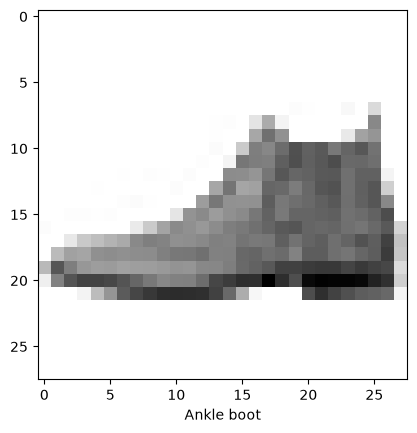

In [17]:
predictions=model.predict(X_test)
prediction_labels=np.argmax(predictions[0])
print('Predicted label:',class_names[prediction_labels])
print('True label:',class_names[y_test[0]])
plt.imshow(X_test[0],cmap=plt.cm.binary)
plt.xlabel(class_names[y_test[0]])
plt.show()


In [32]:
#improvising the model using cnn(convolutional neural network)
model=keras.Sequential([keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
                          keras.layers.MaxPooling2D((2,2)),
                          keras.layers.Flatten(),
                          keras.layers.Dense(64,activation='relu'),
                          keras.layers.Dense(10,activation='softmax') ])


In [26]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)


In [33]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5)
model.evaluate(X_test,y_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1218s 31ms/step - accuracy: 0.6668 - loss: 0.9263
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.7835 - loss: 0.5889
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8084 - loss: 0.5286
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8247 - loss: 0.4925
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.8346 - loss: 0.4697
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8279 - loss: 0.4854


[0.4853871464729309, 0.8278999924659729]

In [34]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f'Train Accuracy: {train_acc*100:.2f}%")')
print(f"Difference: {(train_acc-test_acc)*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8279 - loss: 0.4854
Test Accuracy: 82.79%
Train Accuracy: 82.86%")
Difference: 0.07%
